In [5]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from pathlib import Path
import pm4py
from pm4py.objects.log.obj import EventLog, Trace, Event

SQLITE_PATH = Path(r"C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\ocel2_commitizen.sqlite")
OBJECT_TYPE = "issue"          # flatten around this object type
TOP_N_VARIANTS = 20            # how many variants to show in the chart
FIGURES_DIR = Path(".")

In [50]:
import os, shutil

# ── Graphviz PATH fix (Windows) ───────────────────────────────────────────────
# Add the Graphviz bin directory to this process's PATH so that pm4py DFG
# visualisations can find the 'dot' executable.
_GRAPHVIZ_CANDIDATES = [
    r"C:\Program Files\Graphviz\bin",
    r"C:\Program Files (x86)\Graphviz\bin",
]
for _p in _GRAPHVIZ_CANDIDATES:
    if os.path.isdir(_p) and _p not in os.environ["PATH"]:
        os.environ["PATH"] += os.pathsep + _p
        print(f"Graphviz PATH added: {_p}")
        break

if shutil.which("dot") is None:
    print("WARNING: 'dot' still not found. Install Graphviz and update _GRAPHVIZ_CANDIDATES.")
else:
    print(f"Graphviz 'dot' found at: {shutil.which('dot')}")

Graphviz PATH added: C:\Program Files\Graphviz\bin
Graphviz 'dot' found at: C:\Program Files\Graphviz\bin\dot.EXE


In [6]:
# Build a flattened event log by joining all event-type subtables for timestamps.
# pm4py 2.7 ocel_flattening only materialises 'user' objects from this schema,
# so we read directly from SQLite and produce a standard pm4py-compatible DataFrame.

SUBTABLES = [
    "event_assigned", "event_closed", "event_commented", "event_committed",
    "event_created", "event_cross_referenced", "event_labeled", "event_merged",
    "event_referenced", "event_renamed", "event_reopened", "event_reviewed",
    "event_review_requested", "event_subscribed", "event_head_ref_deleted",
    "event_head_ref_force_pushed", "event_ready_for_review",
    "event_convert_to_draft", "event_unlabeled", "event_milestoned",
    "event_demilestoned", "event_unassigned", "event_mentioned",
    "event_auto_merge_disabled", "event_auto_rebase_enabled",
    "event_auto_squash_enabled", "event_base_ref_changed",
    "event_base_ref_deleted", "event_base_ref_force_pushed",
    "event_connected", "event_converted_to_discussion",
    "event_copilot_work_finished", "event_copilot_work_started",
    "event_head_ref_restored", "event_issue_type_added",
    "event_issue_type_changed", "event_locked", "event_parent_issue_added",
    "event_pinned", "event_review_request_removed",
    "event_sub_issue_added", "event_unsubscribed", "event_unpinned",
]

CONN = sqlite3.connect(SQLITE_PATH)

union_sql = " UNION ALL ".join(
    f"SELECT ocel_id, ocel_time FROM {t}" for t in SUBTABLES
)
times_df = pd.read_sql(union_sql, CONN)

events_df = pd.read_sql(
    "SELECT e.ocel_id, em.ocel_type_map AS activity, eo.ocel_object_id "
    "FROM event e "
    "JOIN event_map_type em ON e.ocel_type = em.ocel_type "
    "JOIN event_object eo ON e.ocel_id = eo.ocel_event_id",
    CONN,
)
case_ids = pd.read_sql(
    f"SELECT ocel_id FROM object WHERE ocel_type = '{OBJECT_TYPE}'", CONN
)["ocel_id"]

flat = (
    events_df
    .merge(times_df, on="ocel_id", how="left")
    .loc[lambda df: df["ocel_object_id"].isin(case_ids)]
    .dropna(subset=["ocel_time"])
    .rename(columns={"ocel_object_id": "case:concept:name",
                     "activity":       "concept:name",
                     "ocel_time":      "time:timestamp"})
    .sort_values(["case:concept:name", "time:timestamp"])
    .reset_index(drop=True)
)
flat["time:timestamp"] = pd.to_datetime(flat["time:timestamp"], utc=True)
CONN.close()

print(f"Flattened log: {len(flat)} events, {flat['case:concept:name'].nunique()} cases")
print(flat[["case:concept:name", "concept:name", "time:timestamp"]].head(10))

Flattened log: 25893 events, 1709 cases
  case:concept:name           concept:name            time:timestamp
0            100019                created 2020-11-21 14:00:43+00:00
1            100019              commented 2020-11-21 14:03:19+00:00
2            100019               reviewed 2020-11-21 14:07:30+00:00
3            100019  head_ref_force_pushed 2020-11-21 15:17:01+00:00
4            100019              committed 2020-11-21 15:31:42+00:00
5            100019  head_ref_force_pushed 2020-11-21 15:31:50+00:00
6            100019                 merged 2020-11-21 15:40:18+00:00
7            100019                 closed 2020-11-21 15:40:18+00:00
8            100062                created 2020-11-21 13:59:15+00:00
9            100062              commented 2020-11-21 14:01:39+00:00


In [7]:
# Convert to pm4py EventLog and compute variants.

log = EventLog()
for case_id, grp in flat.groupby("case:concept:name", sort=False):
    trace = Trace()
    trace.attributes["concept:name"] = str(case_id)
    for _, row in grp.iterrows():
        ev = Event()
        ev["concept:name"]   = row["concept:name"]
        ev["time:timestamp"] = row["time:timestamp"]
        trace.append(ev)
    log.append(trace)

variants = pm4py.get_variants(log)   # dict: variant_tuple -> list[Trace]

variant_counts = {v: len(traces) for v, traces in variants.items()}
variant_df = (
    pd.DataFrame(
        [(">".join(v), cnt) for v, cnt in variant_counts.items()],
        columns=["variant", "count"],
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
variant_df["coverage_%"] = (
    variant_df["count"] / variant_df["count"].sum() * 100
).round(2)
variant_df["cumulative_%"] = variant_df["coverage_%"].cumsum().round(2)

n_cases  = variant_df["count"].sum()
n_vars   = len(variant_df)
top1_cov = variant_df.iloc[0]["coverage_%"]
print(f"Cases: {n_cases} | Distinct variants: {n_vars}")
print(f"Top-1 variant covers {top1_cov:.1f}% of cases")
print(variant_df.head(TOP_N_VARIANTS).to_string(index=False))

Cases: 1709 | Distinct variants: 1259
Top-1 variant covers 3.7% of cases
                                                                                                                                 variant  count  coverage_%  cumulative_%
            committed>created>review_requested>labeled>review_requested>review_requested>labeled>reviewed>merged>closed>head_ref_deleted     64        3.74          3.74
            committed>created>labeled>review_requested>review_requested>review_requested>labeled>reviewed>merged>closed>head_ref_deleted     43        2.52          6.26
                                                                                                        created>labeled>commented>closed     19        1.11          7.37
                                                                              committed>created>commented>merged>closed>head_ref_deleted     19        1.11          8.48
                                                   committed>created>commente

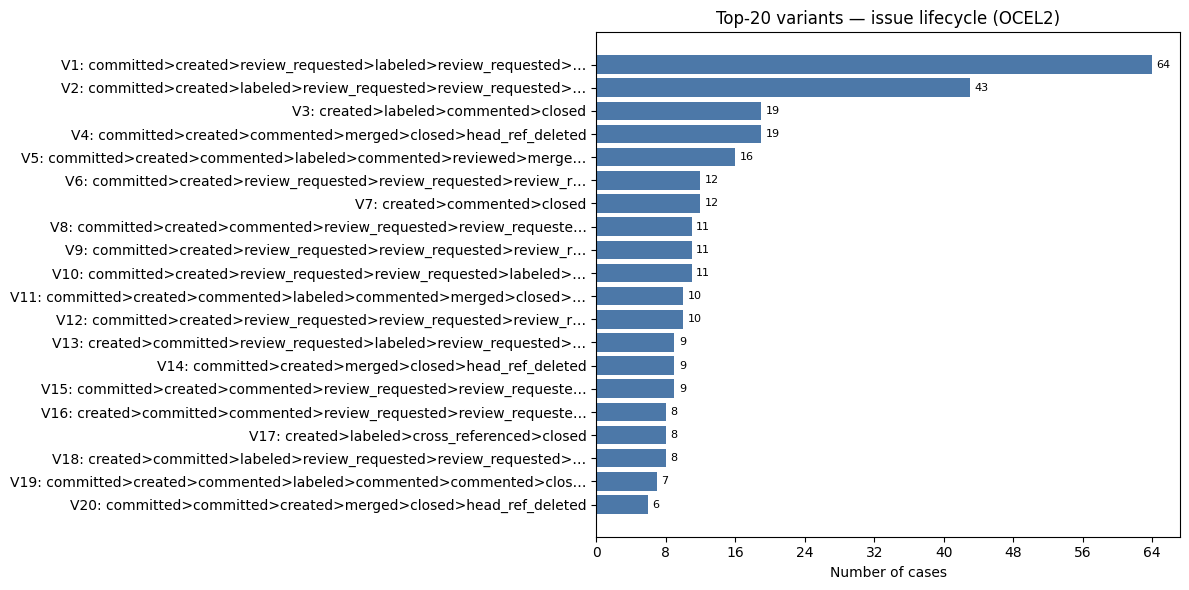

Saved ocel2_variant_analysis.png


In [8]:
# Variant frequency horizontal bar chart.

plot_df = variant_df.head(TOP_N_VARIANTS).copy()
plot_df["short_label"] = [
    f"V{i+1}: {v[:60]}{'\u2026' if len(v) > 60 else ''}"
    for i, v in enumerate(plot_df["variant"])
]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    plot_df["short_label"][::-1],
    plot_df["count"][::-1],
    color="#4C78A8",
)
for bar, cnt in zip(bars, plot_df["count"][::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        str(cnt), va="center", fontsize=8,
    )

ax.set_xlabel("Number of cases")
ax.set_title(f"Top-{TOP_N_VARIANTS} variants — {OBJECT_TYPE} lifecycle (OCEL2)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ocel2_variant_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {FIGURES_DIR / 'ocel2_variant_analysis.png'}")

### variant analysis in anomaly weeks

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
# Load anomaly object IDs
anomaly_df = pd.read_csv("anomaly_object_ids.csv")
anomaly_df["object_id"] = anomaly_df["object_id"].astype(str)

print(f"Anomaly objects: {anomaly_df['object_id'].nunique()} unique, "
      f"{anomaly_df['week_start'].nunique()} anomaly weeks")
anomaly_df.head()

Anomaly objects: 421 unique, 25 anomaly weeks


,week_start,object_id
0,2019-04-15,116370
1,2019-04-15,116396
2,2019-04-15,116442
3,2019-04-15,116518
4,2019-04-15,116547


In [15]:
# Right-join anomaly_df (left) onto flat (right) on object_id / case:concept:name.
# how='right' keeps every row in flat; week_start is populated for anomaly objects, NaN otherwise.
anomaly_events_df = flat[
    flat["case:concept:name"].isin(anomaly_df["object_id"])
].copy()

print(f"Anomaly events df: {len(anomaly_events_df)} rows, "
      f"{anomaly_events_df['case:concept:name'].nunique()} cases")
anomaly_events_df.head()

Anomaly events df: 6831 rows, 421 cases


,ocel_id,concept:name,case:concept:name,time:timestamp
190,100772,created,100768,2020-11-02 14:58:06+00:00
191,100777,labeled,100768,2020-11-02 14:58:06+00:00
192,100780,commented,100768,2020-11-04 11:21:12+00:00
193,100784,commented,100768,2020-11-04 11:32:33+00:00
194,100788,commented,100768,2020-11-11 10:10:59+00:00


In [16]:
# Build pm4py EventLog from anomaly_events_df and compute variants.
anomaly_log = EventLog()
for case_id, grp in anomaly_events_df.groupby("case:concept:name", sort=False):
    trace = Trace()
    trace.attributes["concept:name"] = str(case_id)
    for _, row in grp.iterrows():
        ev = Event()
        ev["concept:name"]   = row["concept:name"]
        ev["time:timestamp"] = row["time:timestamp"]
        trace.append(ev)
    anomaly_log.append(trace)

anomaly_variants = pm4py.get_variants(anomaly_log)

anomaly_variant_counts = {v: len(traces) for v, traces in anomaly_variants.items()}
anomaly_variant_df = (
    pd.DataFrame(
        [(">".join(v), cnt) for v, cnt in anomaly_variant_counts.items()],
        columns=["variant", "count"],
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
anomaly_variant_df["coverage_%"] = (
    anomaly_variant_df["count"] / anomaly_variant_df["count"].sum() * 100
).round(2)
anomaly_variant_df["cumulative_%"] = anomaly_variant_df["coverage_%"].cumsum().round(2)

n_cases_a  = anomaly_variant_df["count"].sum()
n_vars_a   = len(anomaly_variant_df)
top1_cov_a = anomaly_variant_df.iloc[0]["coverage_%"]
print(f"Cases: {n_cases_a} | Distinct variants: {n_vars_a}")
print(f"Top-1 variant covers {top1_cov_a:.1f}% of cases")
print(anomaly_variant_df.head(TOP_N_VARIANTS).to_string(index=False))

Cases: 421 | Distinct variants: 373
Top-1 variant covers 1.7% of cases
                                                                                                                                       variant  count  coverage_%  cumulative_%
                                                                                    committed>created>commented>merged>closed>head_ref_deleted      7        1.66          1.66
                                                                                              committed>created>merged>closed>head_ref_deleted      6        1.43          3.09
                                                                                                              created>labeled>commented>closed      5        1.19          4.28
                                                                                                      created>labeled>labeled>commented>closed      4        0.95          5.23
        committed>created>labeled>labeled>comment

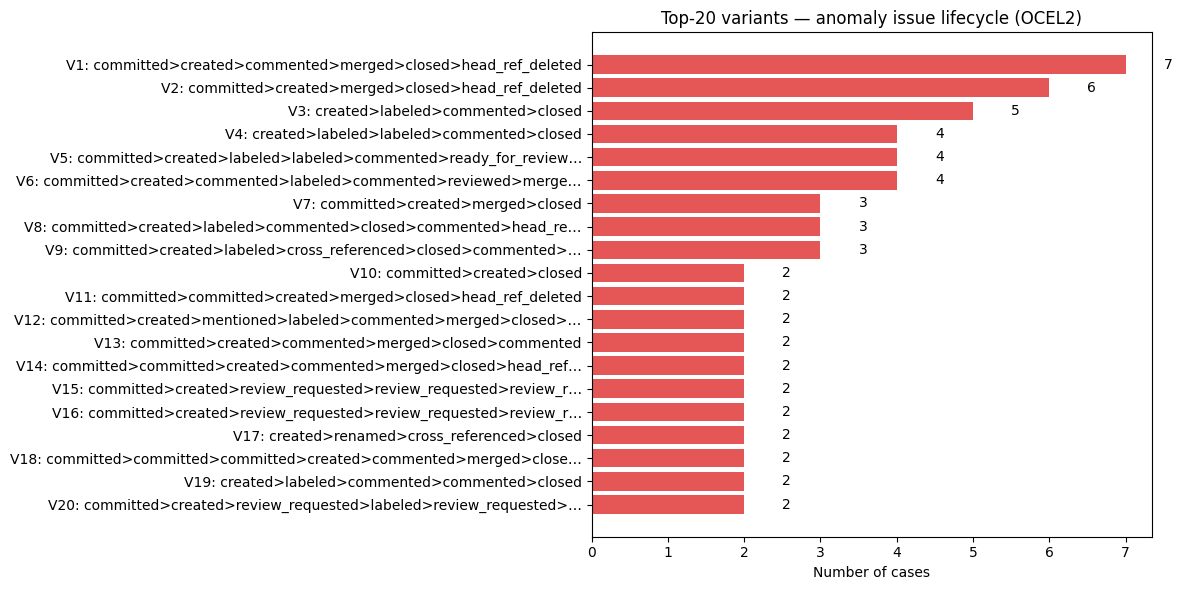

Saved ocel2_variant_analysis_anomaly.png


In [ ]:
# Variant frequency horizontal bar chart — anomaly events.
plot_df_a = anomaly_variant_df.head(TOP_N_VARIANTS).copy()
plot_df_a["short_label"] = [
    f"V{i+1}: {v[:60]}{'\u2026' if len(v) > 60 else ''}"
    for i, v in enumerate(plot_df_a["variant"])
]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    plot_df_a["short_label"][::-1],
    plot_df_a["count"][::-1],
    color="#E45756",
)
for bar, cnt in zip(bars, plot_df_a["count"][::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        str(cnt), va="center", fontsize=8,
    )

ax.set_xlabel("Number of cases")
ax.set_title(f"Top-{TOP_N_VARIANTS} variants — anomaly {OBJECT_TYPE} lifecycle (OCEL2)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ocel2_variant_analysis_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {FIGURES_DIR / 'ocel2_variant_analysis_anomaly.png'}")

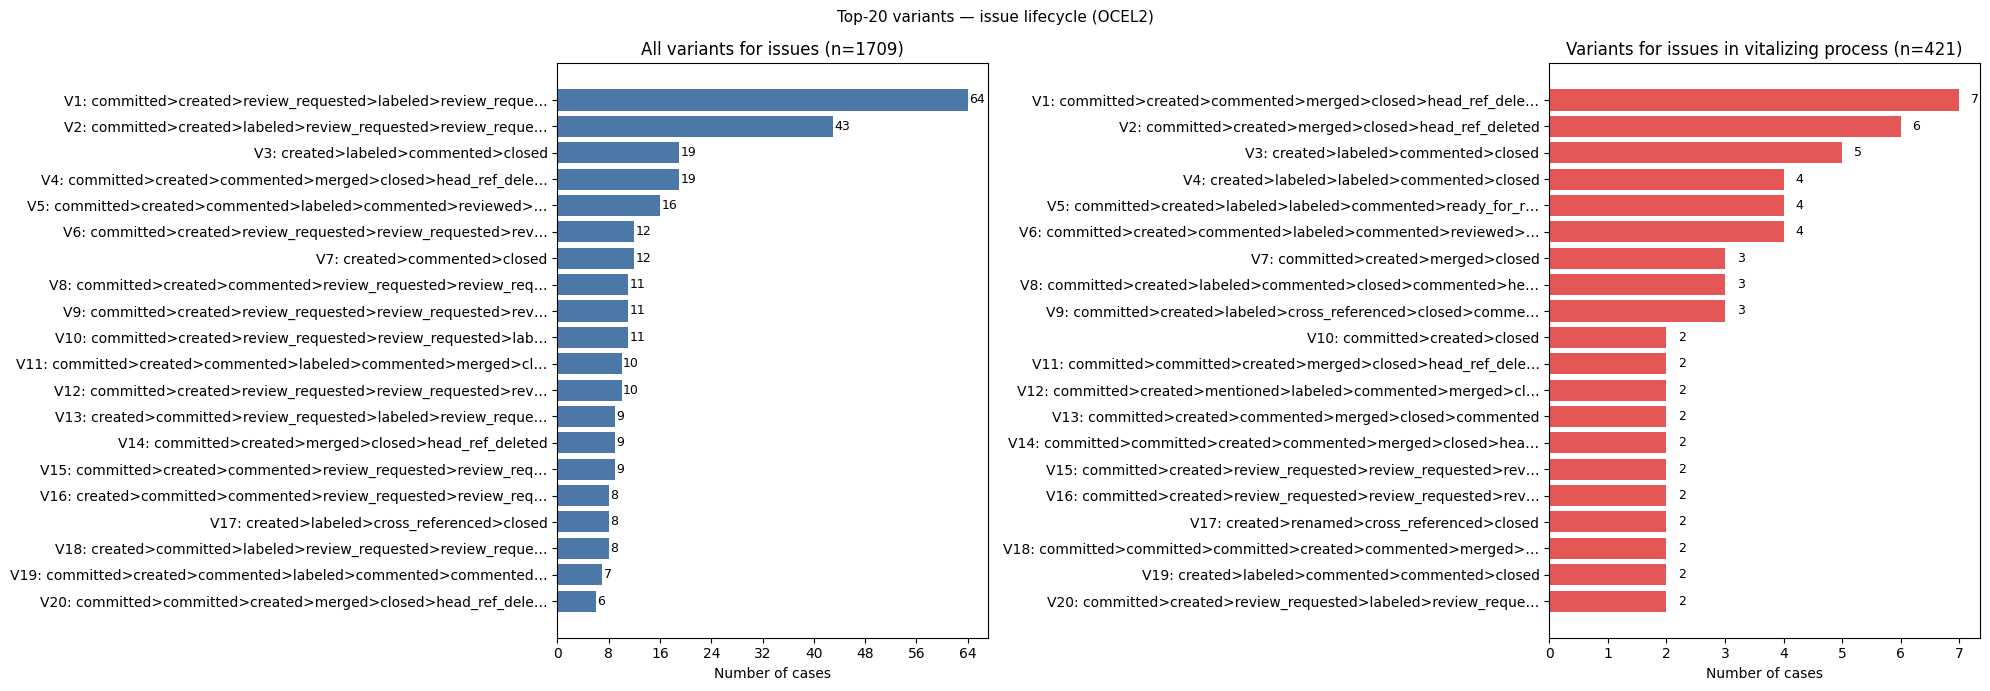

Saved ocel2_variant_comparison.png


In [68]:
# Side-by-side comparison: all-issues variants vs anomaly-issues variants.
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, df, title, color in [
    (axes[0], variant_df,         f"All variants for issues (n={variant_df['count'].sum()})",         "#4C78A8"),
    (axes[1], anomaly_variant_df, f"Variants for issues in vitalizing process (n={anomaly_variant_df['count'].sum()})", "#E45756"),
]:
    plot = df.head(TOP_N_VARIANTS).copy()
    plot["short_label"] = [
        f"V{i+1}: {v[:55]}{'…' if len(v) > 55 else ''}"
        for i, v in enumerate(plot["variant"])
    ]
    bars = ax.barh(plot["short_label"][::-1], plot["count"][::-1], color=color)
    for bar, cnt in zip(bars, plot["count"][::-1]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                str(cnt), va="center", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Number of cases")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle(f"Top-{TOP_N_VARIANTS} variants — {OBJECT_TYPE} lifecycle (OCEL2)", fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ocel2_variant_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {FIGURES_DIR / 'ocel2_variant_comparison.png'}")

C:\Users\mahsa.choopannezhadm\AppData\Local\Temp\ipykernel_30912\1627374973.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


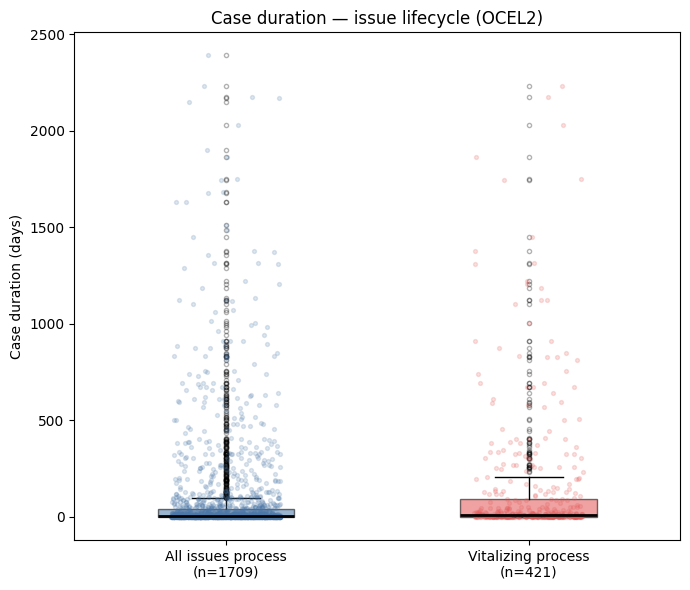

Saved ocel2_case_duration_boxplot.png


In [65]:
# ── Standalone case duration boxplot ─────────────────────────────────────────
import random

rng = random.Random(42)

groups  = [dur_all, dur_anomaly]
colors  = ["#4C78A8", "#E45756"]
labels  = [f"All issues process\n(n={len(dur_all)})", f"Vitalizing process\n(n={len(dur_anomaly)})"]

fig, ax = plt.subplots(figsize=(7, 6))

bp = ax.boxplot(
    groups,
    labels=labels,
    patch_artist=True,
    widths=0.45,
    flierprops=dict(marker="o", markersize=3, linestyle="none", alpha=0.3),
    medianprops=dict(linewidth=2, color="black"),
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

for i, (data, color) in enumerate(zip(groups, colors), start=1):
    x_jitter = [i + rng.uniform(-0.18, 0.18) for _ in data]
    ax.scatter(x_jitter, data, alpha=0.18, s=8, color=color, zorder=2)

ax.set_ylabel("Case duration (days)")
ax.set_title(f"Case duration — {OBJECT_TYPE} lifecycle (OCEL2)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "ocel2_case_duration_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {FIGURES_DIR / 'ocel2_case_duration_boxplot.png'}")